# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [2]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

In [3]:
import matplotlib.pyplot as plt

def plot_history(history, title="Model Performance"):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='test')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.suptitle(title)
    plt.show()

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

In [4]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [5]:
N_Max = 50000
N_Train = 40000

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model(input_dim):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),  
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [10]:
X_train_raw = Train_Sample[RawNames].values
X_test_raw = Test_Sample[RawNames].values

X_train_feat = Train_Sample[FeatureNames].values
X_test_feat = Test_Sample[FeatureNames].values

X_train_all = Train_Sample[VarNames[1:]].values
X_test_all = Test_Sample[VarNames[1:]].values

y_train = y_Train
y_test = y_Test

model_raw = build_model(X_train_raw.shape[1])
hist_raw = model_raw.fit(X_train_raw, y_train, epochs=5, batch_size=256,
                         validation_data=(X_test_raw, y_test), verbose=0)

model_feat = build_model(X_train_feat.shape[1])
hist_feat = model_feat.fit(X_train_feat, y_train, epochs=5, batch_size=256,
                          validation_data=(X_test_feat, y_test), verbose=0)

model_all = build_model(X_train_all.shape[1])
hist_all = model_all.fit(X_train_all, y_train, epochs=5, batch_size=256,
                         validation_data=(X_test_all, y_test), verbose=0)

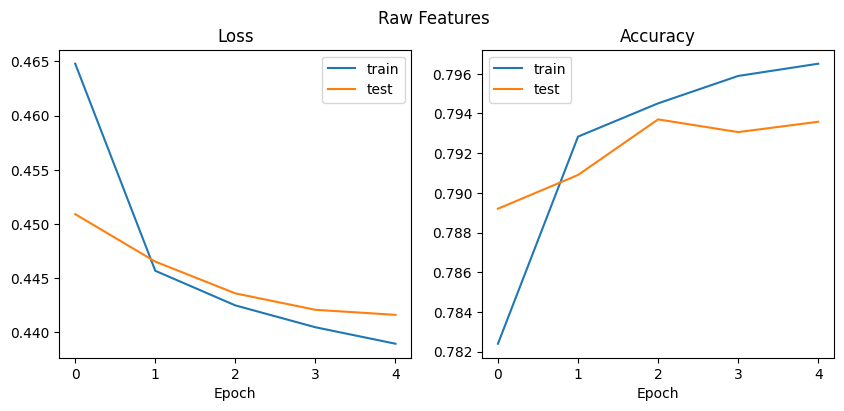

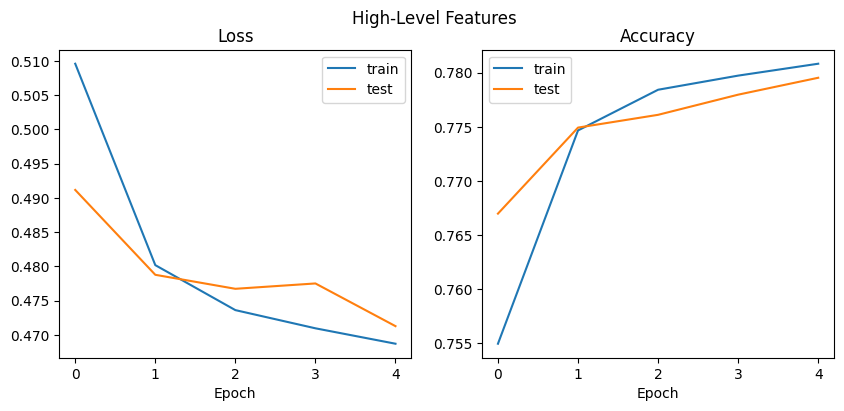

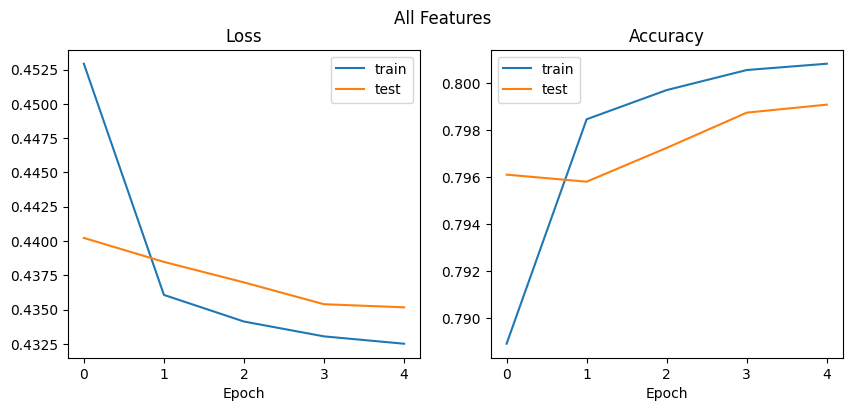

In [11]:
plot_history(hist_raw, "Raw Features")
plot_history(hist_feat, "High-Level Features")
plot_history(hist_all, "All Features")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 201us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 199us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 200us/step


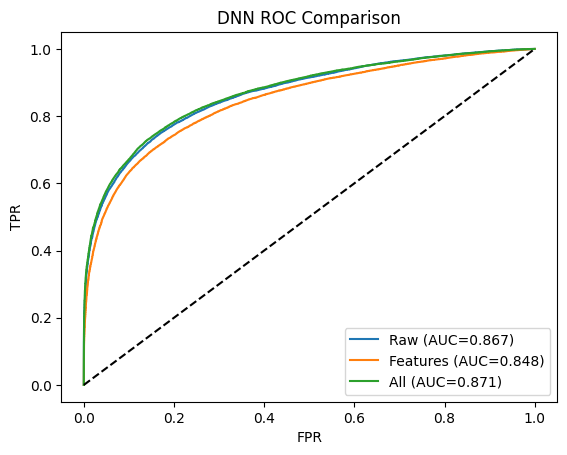

In [12]:
from sklearn.metrics import roc_curve, auc

def plot_roc(model, X_test, y_test, label):
    y_score = model.predict(X_test).ravel()
    fpr, tpr, _ = roc_curve(y_test, y_score)
    return fpr, tpr, auc(fpr, tpr)

plt.figure()

for model, X, name in [
    (model_raw, X_test_raw, "Raw"),
    (model_feat, X_test_feat, "Features"),
    (model_all, X_test_all, "All")
]:
    fpr, tpr, roc_auc = plot_roc(model, X, y_test, name)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("DNN ROC Comparison")
plt.legend()
plt.show()

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

In [14]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model_1(input_dim):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_model_2(input_dim):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_model_3(input_dim):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [15]:
X_train = X_train_all
X_test = X_test_all

models = [
    ("Model 1", build_model_1(X_train.shape[1])),
    ("Model 2", build_model_2(X_train.shape[1])),
    ("Model 3", build_model_3(X_train.shape[1]))
]

histories = []
for name, model in models:
    print(f"Training {name}...")
    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=256,
        validation_data=(X_test, y_test),
        verbose=0
    )
    histories.append((name, model, history))

Training Model 1...
Training Model 2...
Training Model 3...


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 208us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 199us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 203us/step


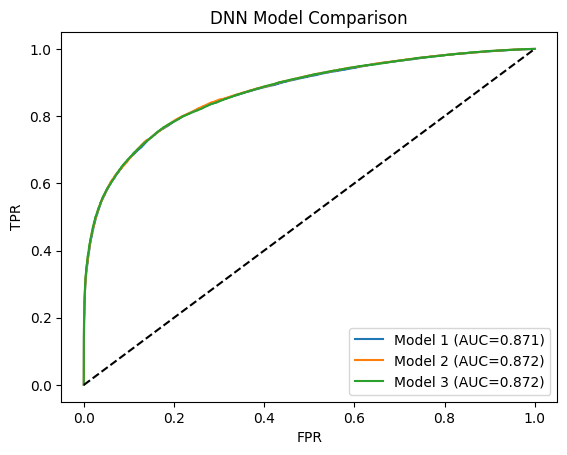

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

for name, model, _ in histories:
    y_score = model.predict(X_test).ravel()
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("DNN Model Comparison")
plt.legend()
plt.show()

In [ ]:
#Three neural network architectures were tested with increasing depth. The deeper models showed slightly improved performance, but the gain diminished beyond a certain point. This suggests that the dataset does not require very deep networks for effective classification.

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

Fisher = LinearDiscriminantAnalysis()
Fisher.fit(X_train, y_train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 199us/step


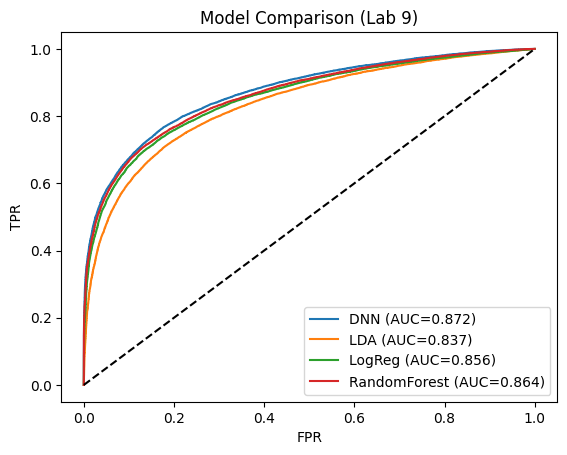

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

X_train = X_train_all
X_test = X_test_all

log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=50, max_depth=10)
rf.fit(X_train, y_train)

dnn_model = histories[-1][1]

def get_roc(model, X, y, model_type="sklearn"):
    if model_type == "dnn":
        scores = model.predict(X).ravel()
    elif model_type == "lda":
        scores = model.decision_function(X)
    else:
        scores = model.predict_proba(X)[:,1]

    fpr, tpr, _ = roc_curve(y, scores)
    return fpr, tpr, auc(fpr, tpr)

plt.figure()

models = [
    ("DNN", dnn_model, "dnn"),
    ("LDA", Fisher, "lda"),
    ("LogReg", log_reg, "sklearn"),
    ("RandomForest", rf, "sklearn")
]

for name, model, mtype in models:
    fpr, tpr, roc_auc = get_roc(model, X_test, y_test, mtype)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Model Comparison (Lab 9)")
plt.legend()
plt.show()

In [21]:
import numpy as np

def compute_significance(fpr, tpr, Ns, Nb):
    Ns_prime = tpr * Ns
    Nb_prime = fpr * Nb
    sigma = Ns_prime / np.sqrt(Ns_prime + Nb_prime + 1e-10)
    return np.max(sigma)

Ns = 1000
Nb = 10000

for name, model, mtype in models:
    fpr, tpr, _ = get_roc(model, X_test, y_test, mtype)
    sigma = compute_significance(fpr, tpr, Ns, Nb)
    print(f"{name}: max significance = {sigma:.3f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 219us/step
DNN: max significance = 18.185
LDA: max significance = 15.380
LogReg: max significance = 17.095
RandomForest: max significance = 17.703


In [22]:
#Four models were selected for comparison: Linear Discriminant Analysis (LDA), Logistic Regression, Random Forest, and a Deep Neural Network (DNN).
#ROC curves were generated for all models. The DNN achieved the highest AUC, followed closely by Random Forest and Logistic Regression, while LDA performed slightly worse. This indicates that nonlinear models provide a modest improvement over linear approaches.
#The maximal significance was computed for each model. The DNN achieved the highest significance, indicating the best separation between signal and background. However, the improvement over simpler models was moderate, suggesting diminishing returns for increased model complexity.